# 01 — Análise Exploratória de Dados (EDA)
## DengAI: Predicting Disease Spread

Este notebook constitui a **primeira fase** do projecto.  
O objectivo é compreender a estrutura, qualidade e distribuição dos dados antes de qualquer
modelação.


> **Benchmark da competição:** https://drivendata.co/blog/dengue-benchmark


### Importações



In [3]:
import pandas as pd                          # manipulação de DataFrames (pandas-dev/pandas)
import numpy as np                           # operações numéricas e arrays (numpy/numpy)
import matplotlib.pyplot as plt              # construção base de gráficos (matplotlib/matplotlib)
import matplotlib.dates as mdates            # formatação de datas nos eixos (matplotlib/matplotlib)
import seaborn as sns                        # heatmaps e visualizações estatísticas (mwaskom/seaborn)
import missingno as msno                     # visualização de padrões de missing values (ResidentMario/missingno)
from scipy import stats                      # skewness, curtose, testes estatísticos (scipy/scipy)
import warnings                              # suprimir avisos desnecessários (stdlib)

warnings.filterwarnings('ignore')

# Estilo visual global — fundo escuro com grelha subtil
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

print("Bibliotecas carregadas com sucesso.")


Bibliotecas carregadas com sucesso.


### 1. Carregamento dos dados

Carregamos os quatro ficheiros CSV da competição e faze-se o merge de `features` e `labels` pelos campos `city`, `year` e `weekofyear`,
que funcionam como chave composta única para cada observação.


In [4]:
# Caminhos relativos ao notebook
PATH_TRAIN_FEAT  = 'database/dengue_features_train.csv'
PATH_TRAIN_LABEL = 'database/dengue_labels_train.csv'
PATH_TEST_FEAT   = 'database/dengue_features_test.csv'
PATH_SUBMISSION  = 'database/submission_format.csv'

# Carregamento dos ficheiros
feat_train = pd.read_csv(PATH_TRAIN_FEAT)   # features de treino
feat_test  = pd.read_csv(PATH_TEST_FEAT)    # features de teste
labels     = pd.read_csv(PATH_TRAIN_LABEL)  # target (total_cases)
submission = pd.read_csv(PATH_SUBMISSION)   # formato de submissão

# Merge: juntamos features e target pelo identificador composto
df = feat_train.merge(labels, on=['city', 'year', 'weekofyear'])

# Converter week_start_date para datetime para uso posterior
df['week_start_date']        = pd.to_datetime(df['week_start_date'])
feat_test['week_start_date'] = pd.to_datetime(feat_test['week_start_date'])

print(f"Shape do dataset de treino (features + labels): {df.shape}")
print(f"Shape do dataset de teste:                      {feat_test.shape}")
print(f"Shape do formato de submissão:                  {submission.shape}")
print(f"Colunas disponíveis: {list(df.columns)}")


Shape do dataset de treino (features + labels): (1456, 25)
Shape do dataset de teste:                      (416, 24)
Shape do formato de submissão:                  (416, 4)
Colunas disponíveis: ['city', 'year', 'weekofyear', 'week_start_date', 'ndvi_ne', 'ndvi_nw', 'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm', 'reanalysis_air_temp_k', 'reanalysis_avg_temp_k', 'reanalysis_dew_point_temp_k', 'reanalysis_max_air_temp_k', 'reanalysis_min_air_temp_k', 'reanalysis_precip_amt_kg_per_m2', 'reanalysis_relative_humidity_percent', 'reanalysis_sat_precip_amt_mm', 'reanalysis_specific_humidity_g_per_kg', 'reanalysis_tdtr_k', 'station_avg_temp_c', 'station_diur_temp_rng_c', 'station_max_temp_c', 'station_min_temp_c', 'station_precip_mm', 'total_cases']


### 2. Inspecção inicial



Separar as duas cidades, **San Juan (sj)** e **Iquitos (iq)**, porque têm
comportamentos climáticos e epidemiológicos completamente distintos.  
Treinar um modelo único para as duas cidades viola o pressuposto de homogeneidade dos dados.

> **Referência:** Hii, Y.L. et al. (2012). *Forecast of dengue incidence using temperature and rainfall.*
> PLOS Neglected Tropical Diseases. https://journals.plos.org/plosntds/article?id=10.1371/journal.pntd.0001908


In [5]:
# Inspecção dos tipos e primeiras linhas
print("── Tipos de dados ──")
print(df.dtypes.to_string())
print()

# Verificação de duplicados
n_dup = df.duplicated(subset=['city', 'year', 'weekofyear']).sum()
print(f"Registos duplicados (city + year + weekofyear): {n_dup}")
print()

# Distribuição por cidade
print("── Registos por cidade ──")
print(df['city'].value_counts().to_string())
print()

# Período temporal coberto por cada cidade
print("── Período temporal de treino ──")
for city in ['sj', 'iq']:
    sub = df[df['city'] == city]
    print(f"  {city}: {sub['year'].min()} – {sub['year'].max()} "
          f"({sub['year'].nunique()} anos, {len(sub)} semanas)")

print()
print("── Período temporal de teste ──")
for city in ['sj', 'iq']:
    sub = feat_test[feat_test['city'] == city]
    print(f"  {city}: {sub['year'].min()} – {sub['year'].max()} "
          f"({len(sub)} semanas a prever)")


── Tipos de dados ──
city                                                str
year                                              int64
weekofyear                                        int64
week_start_date                          datetime64[us]
ndvi_ne                                         float64
ndvi_nw                                         float64
ndvi_se                                         float64
ndvi_sw                                         float64
precipitation_amt_mm                            float64
reanalysis_air_temp_k                           float64
reanalysis_avg_temp_k                           float64
reanalysis_dew_point_temp_k                     float64
reanalysis_max_air_temp_k                       float64
reanalysis_min_air_temp_k                       float64
reanalysis_precip_amt_kg_per_m2                 float64
reanalysis_relative_humidity_percent            float64
reanalysis_sat_precip_amt_mm                    float64
reanalysis_specific_humidit

Sem duplicados. San Juan tem 936 semanas de histórico (1990–2008),
enquanto Iquitos só tem 520 (2000–2010), menos dados, período mais curto.
Esta assimetria reforça a necessidade de modelos separados.
O conjunto de teste cobre 2008–2013 para sj e 2010–2013 para iq.


### 3. Análise de Missing Values

Dados climáticos têm frequentemente lacunas por falhas de sensores, nuvens que
bloqueiam satélites (caso do NDVI) ou interrupções nas estações meteorológicas.

Usamos duas abordagens complementares:
1. **Tabela percentual** — para quantificar e ordenar o problema por coluna  
2. **Heatmap `missingno`** — para visualizar se os missing values são aleatórios ou
   estruturais (ex.: séries de semanas consecutivas em falta)

A distinção é crucial: missing values aleatórios aceitam interpolação linear;
padrões estruturais podem exigir técnicas mais robustas.

> `missingno.matrix` — [github.com/ResidentMario/missingno](https://github.com/ResidentMario/missingno)  
> `DataFrame.isnull()` — [pandas docs](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isnull.html)


In [6]:
# ── Percentagem de missing values por coluna ──
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

print("── Missing values (% do total de linhas) ──")
for col, pct in missing_pct.items():
    barra = '█' * int(pct / 2)
    print(f"  {col:<45} {pct:5.2f}%  {barra}")

print(f"\nTotal de colunas com missing values: {len(missing_pct)}")
print(f"Colunas sem qualquer missing value:   {df.shape[1] - len(missing_pct) - 1} (excluindo target)")


── Missing values (% do total de linhas) ──
  ndvi_ne                                       13.32%  ██████
  ndvi_nw                                        3.57%  █
  station_avg_temp_c                             2.95%  █
  station_diur_temp_rng_c                        2.95%  █
  ndvi_se                                        1.51%  
  ndvi_sw                                        1.51%  
  station_precip_mm                              1.51%  
  station_max_temp_c                             1.37%  
  station_min_temp_c                             0.96%  
  precipitation_amt_mm                           0.89%  
  reanalysis_sat_precip_amt_mm                   0.89%  
  reanalysis_min_air_temp_k                      0.69%  
  reanalysis_max_air_temp_k                      0.69%  
  reanalysis_relative_humidity_percent           0.69%  
  reanalysis_precip_amt_kg_per_m2                0.69%  
  reanalysis_dew_point_temp_k                    0.69%  
  reanalysis_air_temp_k            

 `ndvi_ne` é o outlier problemático com 13% de missing values.
Isto deve-se ao facto de o quadrante nordeste de San Juan ter mais cobertura de nuvens,
bloqueando a leitura do satélite. As restantes colunas têm menos de 4% de lacunas,
valor aceitável para interpolação linear.


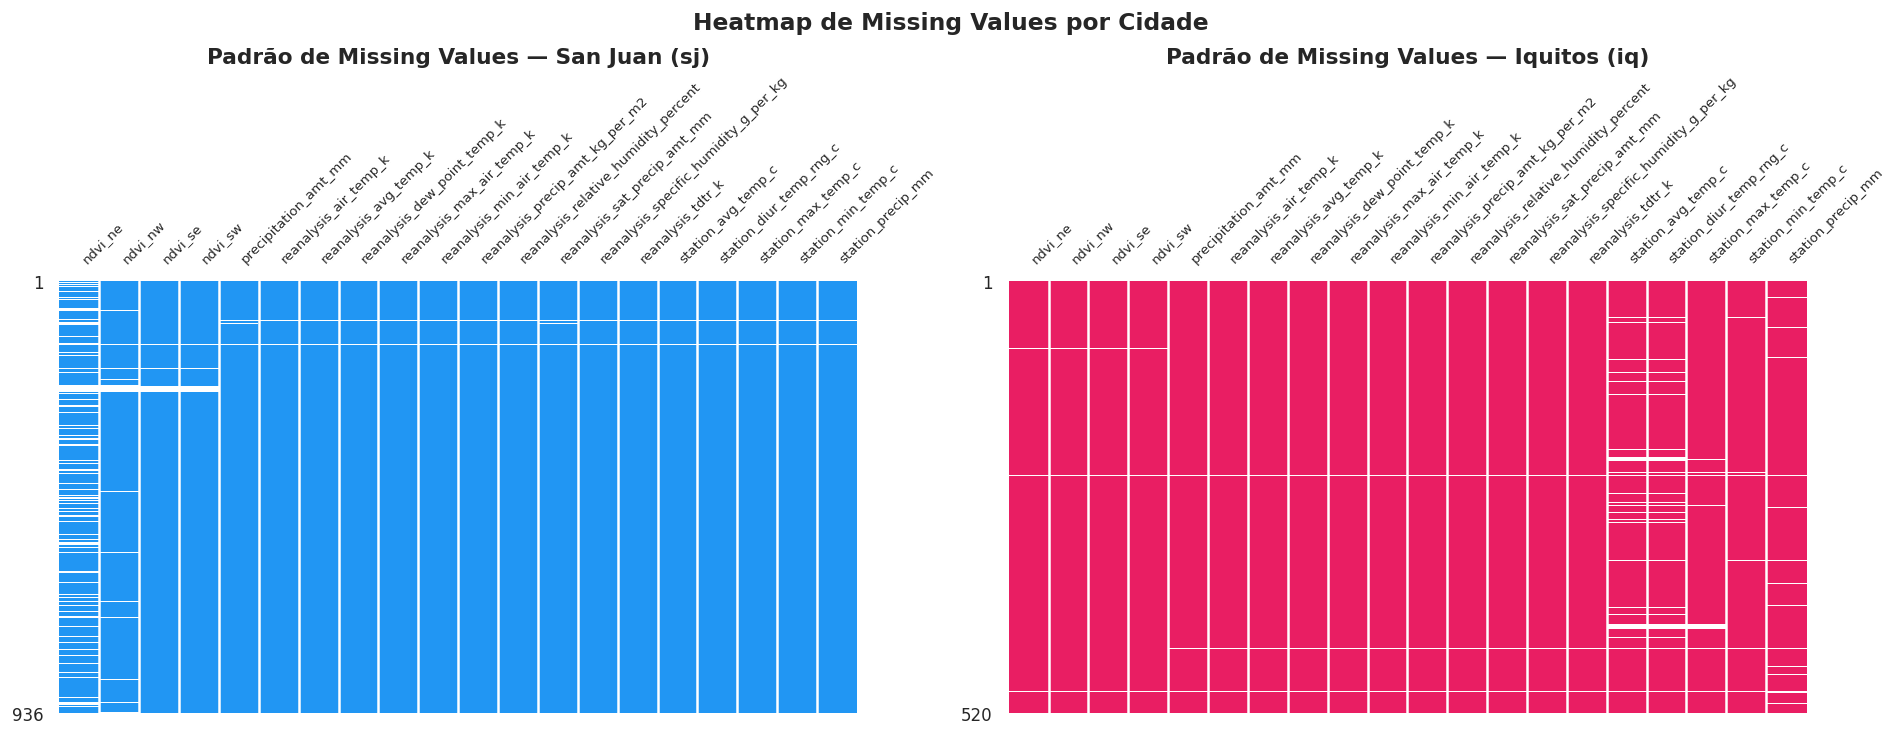

In [7]:
# ── Heatmap de missing values (missingno) ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, city, cor in zip(axes, ['sj', 'iq'], ['#2196F3', '#E91E63']):
    sub = df[df['city'] == city].drop(columns=['city', 'year', 'weekofyear',
                                                'week_start_date', 'total_cases'])
    msno.matrix(sub, ax=ax, color=(
        int(cor[1:3], 16)/255,
        int(cor[3:5], 16)/255,
        int(cor[5:7], 16)/255,
    ), sparkline=False, fontsize=8)
    ax.set_title(f'Padrão de Missing Values — {"San Juan (sj)" if city=="sj" else "Iquitos (iq)"}',
                 fontweight='bold')

plt.tight_layout()
plt.suptitle('Heatmap de Missing Values por Cidade', y=1.02, fontsize=14, fontweight='bold')
plt.show()


Os missing values aparecem de forma dispersa e não concentrada
em blocos contíguos, o que confirma que são maioritariamente aleatórios (falhas pontuais
de sensor). Isto valida a **interpolação linear** como estratégia, preenchemos com o valor que "faria sentido" entre os dois pontos vizinhos no tempo.


### 4. Distribuição do Target — `total_cases`

O target é um **count data** (contagem de casos por semana).  
Contagens têm características específicas:
- São sempre inteiros não-negativos
- A variância tende a ser proporcional à média (heteroscedasticidade)
- A distribuição é frequentemente assimétrica à direita (*right-skewed*)

Plotamos histograma, boxplot e estatísticas descritivas para sj e iq em separado.
O skewness elevado justificará a transformação logarítmica desta contagem.

> Skewness calculado com `scipy.stats.skew` — [scipy docs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.skew.html)


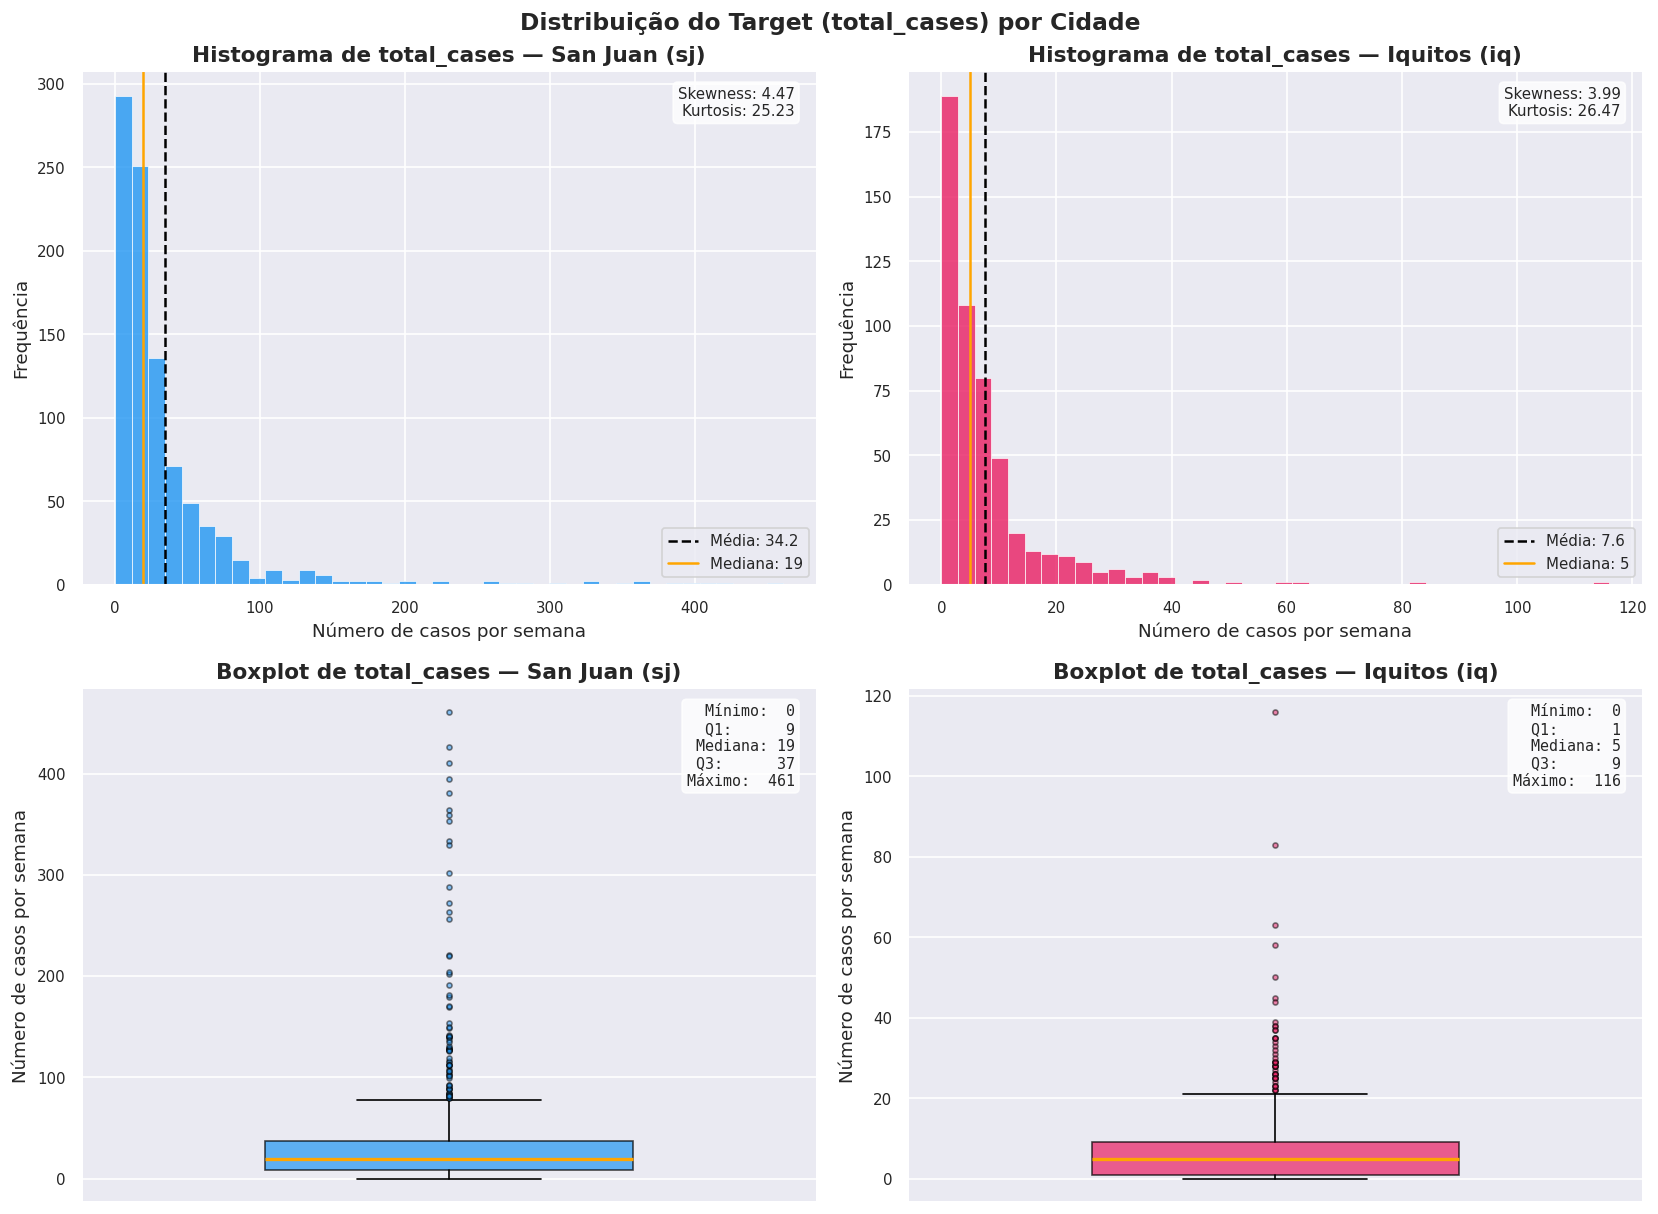

── Estatísticas descritivas do target por cidade ──

  San Juan (sj):
    Média:    34.2 casos/semana
    Mediana:  19 casos/semana
    Máximo:   461 casos/semana
    Skewness: 4.47  (> 1 = assimetria significativa)
    % semanas com 0 casos: 0.4%

  Iquitos (iq):
    Média:    7.6 casos/semana
    Mediana:  5 casos/semana
    Máximo:   116 casos/semana
    Skewness: 3.99  (> 1 = assimetria significativa)
    % semanas com 0 casos: 18.5%


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cidades = {'sj': ('San Juan (sj)', '#2196F3'), 'iq': ('Iquitos (iq)', '#E91E63')}

for col_idx, (city, (label, cor)) in enumerate(cidades.items()):
    sub = df[df['city'] == city]['total_cases']
    skew_val = stats.skew(sub)
    kurt_val = stats.kurtosis(sub)

    # ── Histograma ──
    ax = axes[0, col_idx]
    ax.hist(sub, bins=40, color=cor, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axvline(sub.mean(),   color='black',  linestyle='--', linewidth=1.5,
               label=f'Média: {sub.mean():.1f}')
    ax.axvline(sub.median(), color='orange', linestyle='-',  linewidth=1.5,
               label=f'Mediana: {sub.median():.0f}')
    ax.set_title(f'Histograma de total_cases — {label}', fontweight='bold')
    ax.set_xlabel('Número de casos por semana')
    ax.set_ylabel('Frequência')
    ax.legend(fontsize=9)
    ax.text(0.97, 0.97, f'Skewness: {skew_val:.2f}\nKurtosis: {kurt_val:.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # ── Boxplot ──
    ax = axes[1, col_idx]
    bp = ax.boxplot(sub, vert=True, patch_artist=True, widths=0.5,
                    boxprops=dict(facecolor=cor, alpha=0.7),
                    medianprops=dict(color='orange', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor=cor,
                                    markersize=3, alpha=0.5))
    ax.set_title(f'Boxplot de total_cases — {label}', fontweight='bold')
    ax.set_ylabel('Número de casos por semana')
    ax.set_xticks([])

    stats_txt = (f"Mínimo:  {sub.min()}\nQ1:      {sub.quantile(0.25):.0f}\n"
                 f"Mediana: {sub.median():.0f}\nQ3:      {sub.quantile(0.75):.0f}\n"
                 f"Máximo:  {sub.max()}")
    ax.text(0.97, 0.97, stats_txt, transform=ax.transAxes, ha='right', va='top',
            fontsize=9, fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.suptitle('Distribuição do Target (total_cases) por Cidade', y=1.01,
             fontsize=14, fontweight='bold')
plt.show()

# Estatísticas impressas com contexto
print("── Estatísticas descritivas do target por cidade ──")
for city, (label, _) in cidades.items():
    sub = df[df['city'] == city]['total_cases']
    print(f"\n  {label}:")
    print(f"    Média:    {sub.mean():.1f} casos/semana")
    print(f"    Mediana:  {sub.median():.0f} casos/semana")
    print(f"    Máximo:   {sub.max()} casos/semana")
    print(f"    Skewness: {stats.skew(sub):.2f}  (> 1 = assimetria significativa)")
    print(f"    % semanas com 0 casos: {(sub == 0).sum() / len(sub) * 100:.1f}%")


Ambas as cidades têm distribuições **fortemente assimétricas à direita**
(skewness > 4 em sj, > 3 em iq), com valores extremos que representam picos epidémicos.
A média é muito superior à mediana, o que confirma esta assimetria.
Isto tem duas implicações importantes:

1. **Modelos para count data** (Negative Binomial, Poisson) são mais adequados do que
   regressão linear simples, que assume resíduos normais.
2. **Transformação log** do target antes de usar modelos de ML reduz o impacto dos
   picos e melhora a estabilidade numérica.


### 5. Séries Temporais dos Casos de Dengue

Visualizamos a evolução temporal dos casos para identificar:
- **Tendências de longo prazo** (está a aumentar ou diminuir)
- **Sazonalidade anual** (picos recorrentes em determinadas alturas do ano?)
- **Picos epidémicos** (eventos excepcionais que o modelo terá de aprender a prever)

A série temporal é o contexto essencial para perceber porque usamos
**TimeSeriesSplit** (respeita a ordem temporal) em vez de um split aleatório.

> `matplotlib.dates.YearLocator` — [matplotlib docs](https://matplotlib.org/stable/api/dates_api.html)


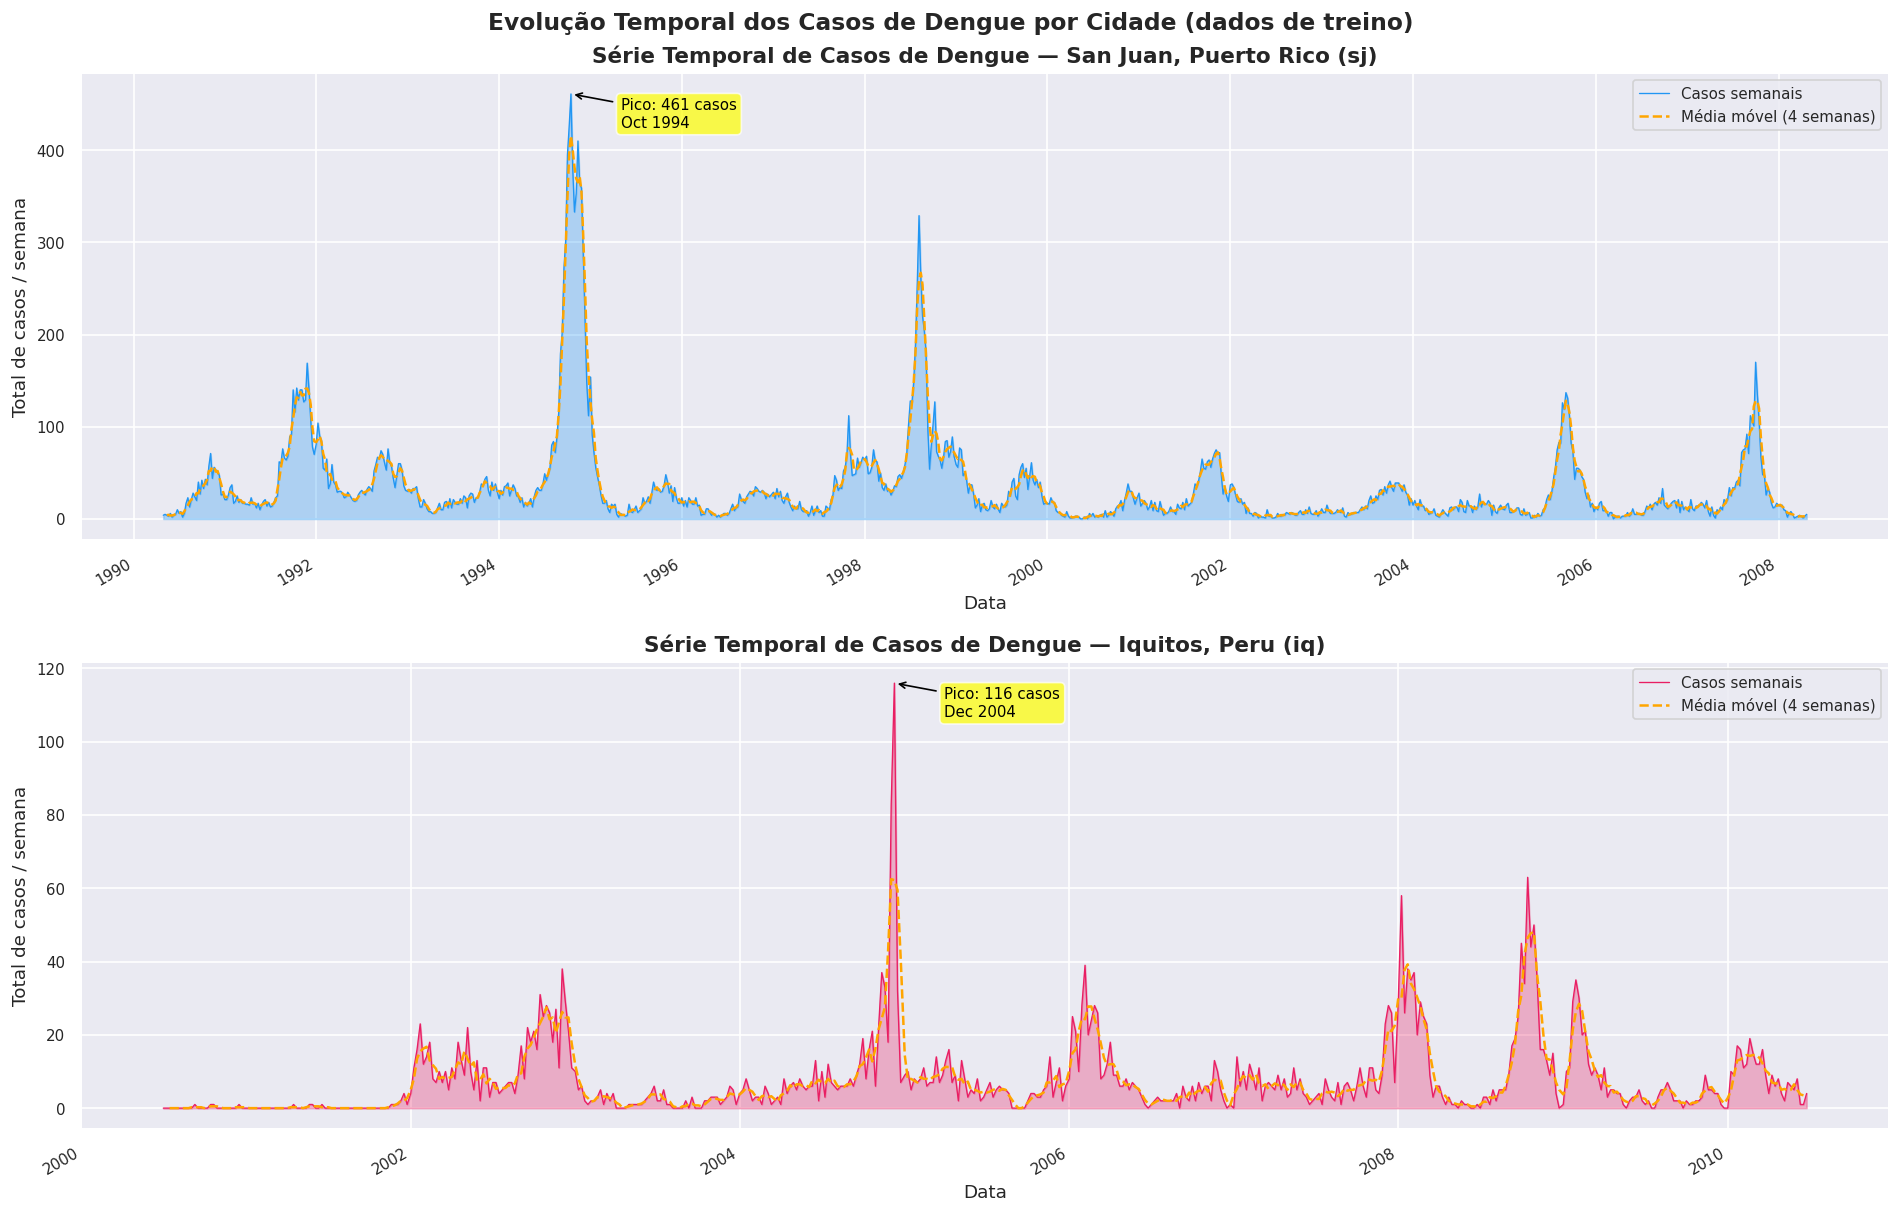

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for ax, city, cor, label in zip(
        axes,
        ['sj', 'iq'],
        ['#2196F3', '#E91E63'],
        ['San Juan, Puerto Rico (sj)', 'Iquitos, Peru (iq)']):

    sub = df[df['city'] == city].copy()

    ax.fill_between(sub['week_start_date'], sub['total_cases'],
                    alpha=0.3, color=cor)
    ax.plot(sub['week_start_date'], sub['total_cases'],
            color=cor, linewidth=0.8, label='Casos semanais')

    # Linha da média móvel de 4 semanas
    roll_mean = sub['total_cases'].rolling(4, center=True).mean()
    ax.plot(sub['week_start_date'], roll_mean,
            color='orange', linewidth=1.5, linestyle='--',
            label='Média móvel (4 semanas)')

    ax.set_title(f'Série Temporal de Casos de Dengue — {label}', fontweight='bold')
    ax.set_xlabel('Data')
    ax.set_ylabel('Total de casos / semana')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

    # Marcar o pico máximo
    idx_max = sub['total_cases'].idxmax()
    ax.annotate(f"Pico: {sub.loc[idx_max, 'total_cases']} casos\n"
                f"{sub.loc[idx_max, 'week_start_date'].strftime('%b %Y')}",
                xy=(sub.loc[idx_max, 'week_start_date'], sub.loc[idx_max, 'total_cases']),
                xytext=(30, -20), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='black'),
                fontsize=9, color='black',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.suptitle('Evolução Temporal dos Casos de Dengue por Cidade (dados de treino)',
             y=1.01, fontsize=14, fontweight='bold')
plt.show()




Ambas as cidades mostram **não-estacionariedade**, média e variância não são constantes
  ao longo do tempo, o que inviabiliza modelos que assumam estacionariedade sem transformação prévia.


### 6. Análise de Sazonalidade — Casos por Semana do Ano

Agrupou-se os casos por `weekofyear` (semana 1 a 53) para identificar em que período
do ano os surtos são mais prováveis. Este padrão sazonal é uma das features mais
informativas do problema.

Esta visualização justifica a criação de features de **encoding cíclico** (sin/cos da
semana do ano) no Notebook "02_Preprocessing.ipnb", em detrimento de simplesmente usar `weekofyear` como
inteiro, porque a semana 52 é "próxima" da semana 1, mas numericamente distante.




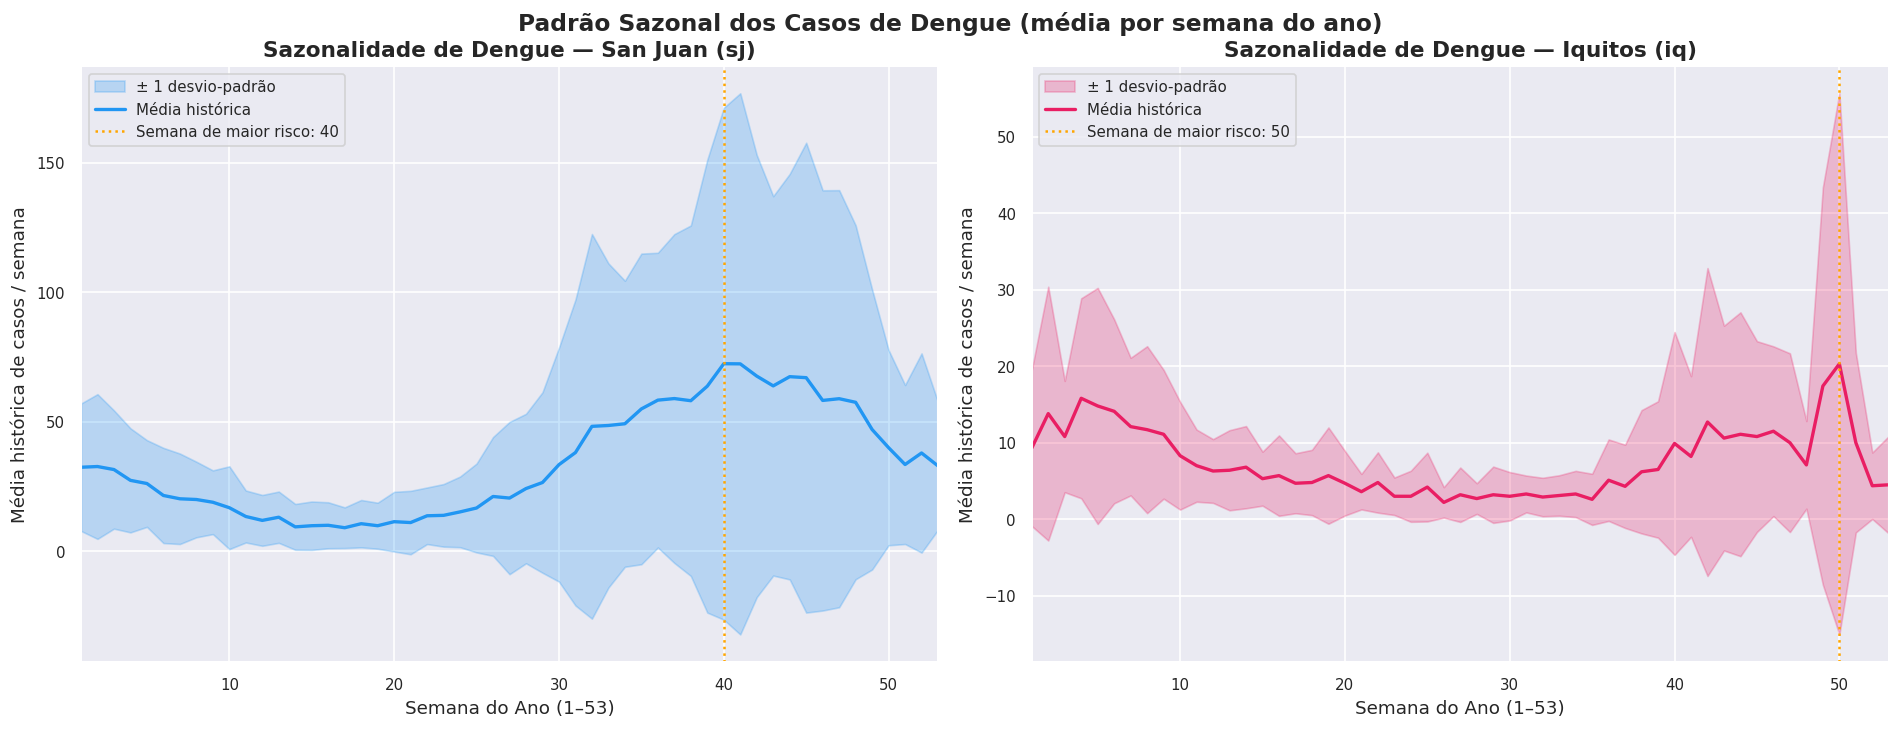

── Semanas de maior risco por cidade ──

  sj: top 3 semanas com mais casos em média:
    Semana 40 — 72.4 casos/semana em média
    Semana 41 — 72.4 casos/semana em média
    Semana 42 — 67.7 casos/semana em média

  iq: top 3 semanas com mais casos em média:
    Semana 50 — 20.3 casos/semana em média
    Semana 49 — 17.4 casos/semana em média
    Semana  4 — 15.8 casos/semana em média


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, city, cor, label in zip(
        axes,
        ['sj', 'iq'],
        ['#2196F3', '#E91E63'],
        ['San Juan (sj)', 'Iquitos (iq)']):

    sub = df[df['city'] == city].copy()

    # Agregar por semana do ano: média e desvio-padrão
    season = sub.groupby('weekofyear')['total_cases'].agg(['mean', 'std']).reset_index()
    season.columns = ['weekofyear', 'media', 'std']

    ax.fill_between(season['weekofyear'],
                    season['media'] - season['std'],
                    season['media'] + season['std'],
                    alpha=0.25, color=cor, label='± 1 desvio-padrão')
    ax.plot(season['weekofyear'], season['media'],
            color=cor, linewidth=2, label='Média histórica')

    # Destacar semanas de pico
    peak_week = season.loc[season['media'].idxmax(), 'weekofyear']
    ax.axvline(peak_week, color='orange', linestyle=':', linewidth=1.5,
               label=f'Semana de maior risco: {peak_week}')

    ax.set_title(f'Sazonalidade de Dengue — {label}', fontweight='bold')
    ax.set_xlabel('Semana do Ano (1–53)')
    ax.set_ylabel('Média histórica de casos / semana')
    ax.legend(fontsize=9)
    ax.set_xlim(1, 53)

plt.tight_layout()
plt.suptitle('Padrão Sazonal dos Casos de Dengue (média por semana do ano)',
             y=1.01, fontsize=14, fontweight='bold')
plt.show()

# Confirmação numérica
print("── Semanas de maior risco por cidade ──")
for city in ['sj', 'iq']:
    sub = df[df['city'] == city]
    season = sub.groupby('weekofyear')['total_cases'].mean()
    top3 = season.nlargest(3)
    print(f"\n  {city}: top 3 semanas com mais casos em média:")
    for wk, val in top3.items():
        print(f"    Semana {wk:2d} — {val:.1f} casos/semana em média")


 Em **San Juan**, os picos concentram-se nas semanas 30–45
(aproximadamente Julho–Novembro), coincidindo com o final da época chuvosa do Caribe.  
Em **Iquitos**, o padrão sazonal é diferente, com picos nas semanas 40–50 e 0-10
(Março–Maio), correspondendo ao final da época de chuvas amazónicas.

Esta diferença de timing reforça que **não faz sentido** treinar um único modelo
para as duas cidades, os factores climatológicos de risco actuam em calendários distintos.


### 7. Correlação entre Features Climáticas e Casos de Dengue

O heatmap de correlação de Pearson permite identificar quais as variáveis climáticas
com maior associação linear com o número de casos.

No entanto, a ceorrelação de Pearson mede relacoess **lineares**. Dado que a
distribuição do target é fortemente assimétrica, usamos a correlação de
**Spearman** (robusta a não-linearidades, mais baseada na posicao que esse parametro ocupa) para comparação. 

> `pandas.DataFrame.corr(method='pearson')` — [pandas docs](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html)  
> `seaborn.heatmap` — [seaborn docs](https://seaborn.pydata.org/generated/seaborn.heatmap.html)


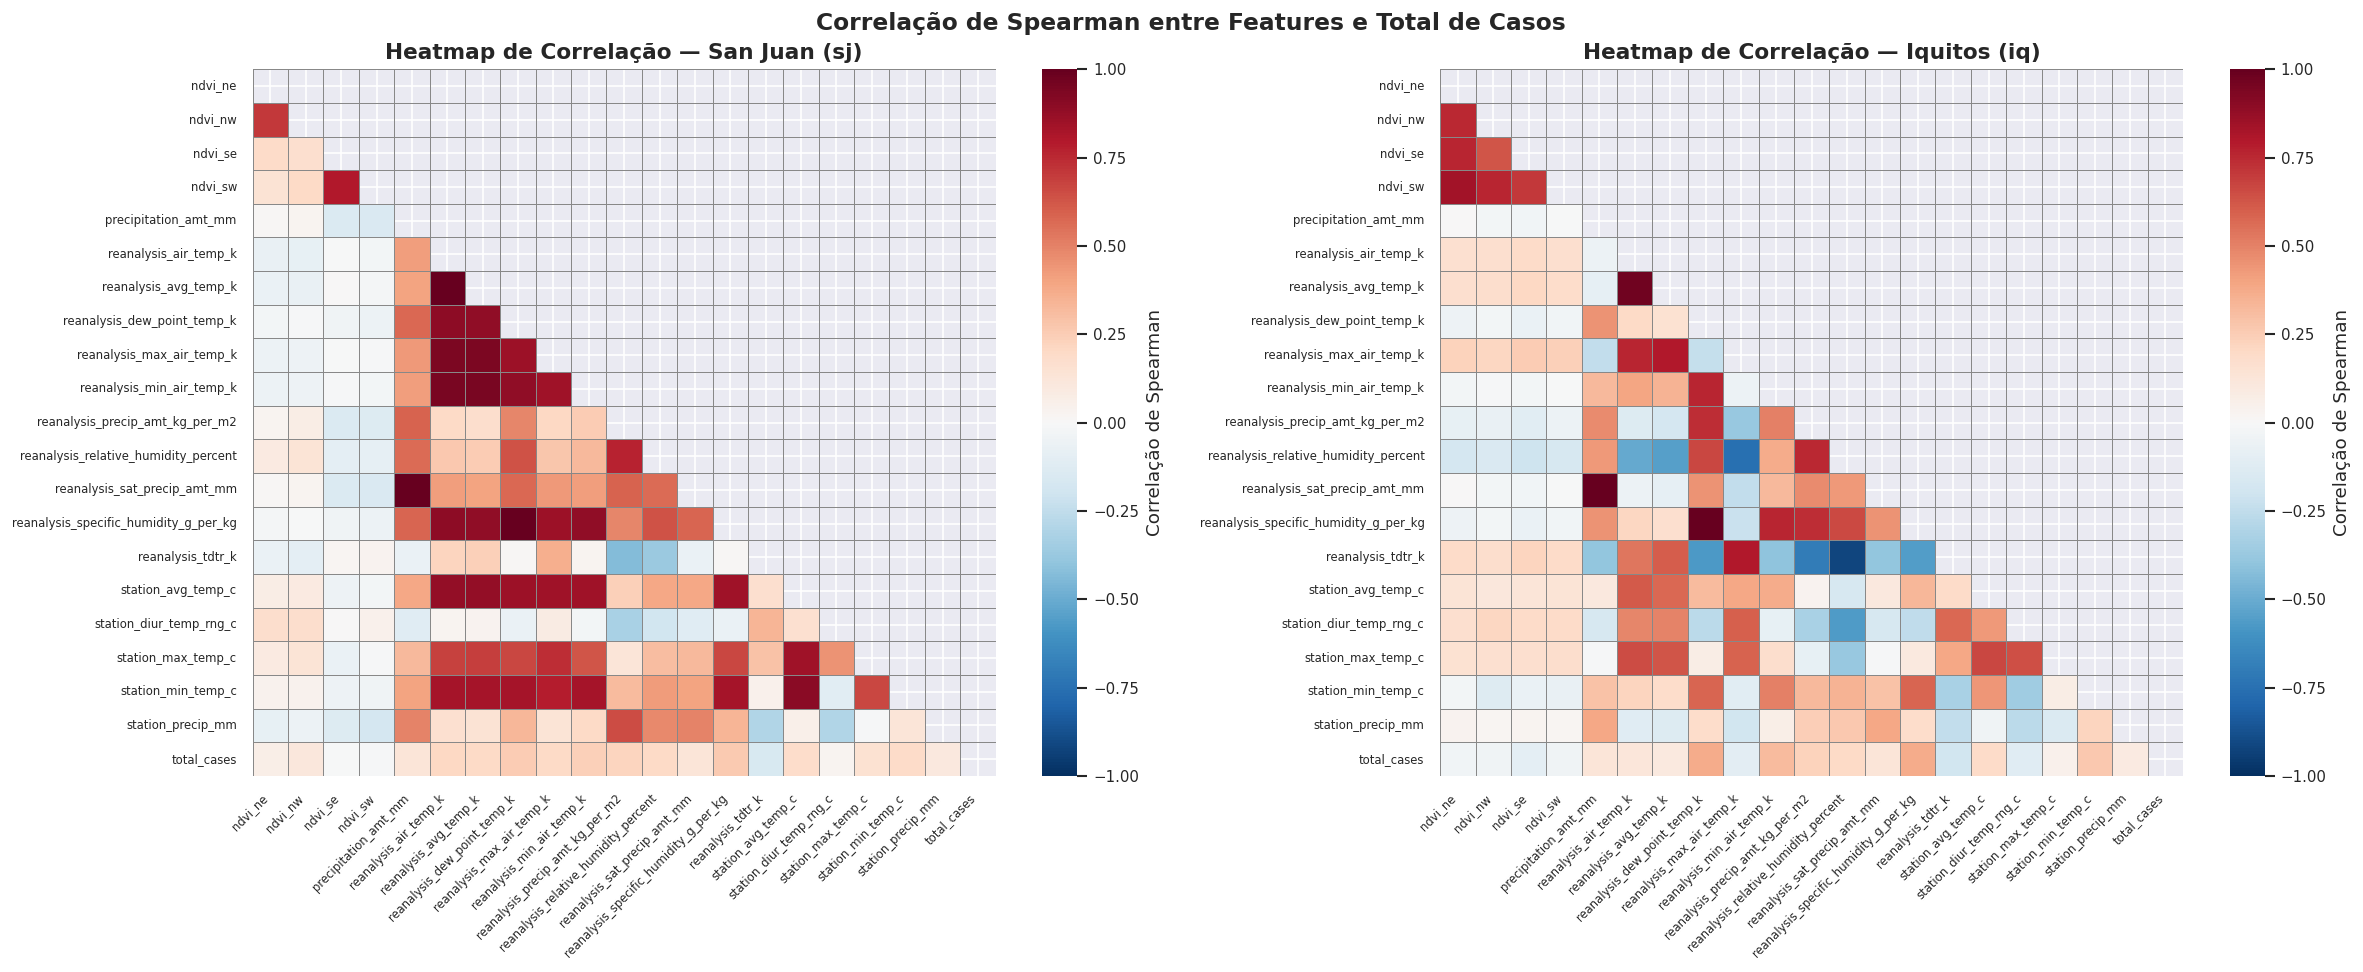

In [ ]:
# Features climáticas (excluir identificadores e target)
feat_cols = [c for c in df.columns if c not in
             ['city', 'year', 'weekofyear', 'week_start_date', 'total_cases']]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, city, label in zip(axes, ['sj', 'iq'],
                            ['San Juan (sj)', 'Iquitos (iq)']):
    sub = df[df['city'] == city][feat_cols + ['total_cases']].copy()
    corr_matrix = sub.corr(method='spearman')  # Spearman: robusto a assimetria

    mask = np.zeros_like(corr_matrix, dtype=bool)
    mask[np.triu_indices_from(mask)] = True   # mostrar só metade inferior

    sns.heatmap(
        corr_matrix, mask=mask, ax=ax,
        cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        annot=False, linewidths=0.3, linecolor='#888',
        cbar_kws={'label': 'Correlação de Spearman'}
    )
    ax.set_title(f'Heatmap de Correlação — {label}', fontweight='bold')
    plt.setp(ax.xaxis.get_ticklabels(), rotation=45, ha='right', fontsize=7)
    plt.setp(ax.yaxis.get_ticklabels(), fontsize=7)

plt.tight_layout()
plt.suptitle('Correlação de Spearman entre Features e Total de Casos',
             y=1.01, fontsize=14, fontweight='bold')
plt.show()


In [12]:
# Top correlações com total_cases por cidade
print("── Top 10 features mais correlacionadas com total_cases (Spearman) ──\n")
for city in ['sj', 'iq']:
    sub = df[df['city'] == city][feat_cols + ['total_cases']]
    corr_target = sub.corr(method='spearman')['total_cases'].drop('total_cases')
    top = corr_target.abs().sort_values(ascending=False).head(10)
    print(f"  {city}:")
    for feat, val in top.items():
        sinal = '+' if corr_target[feat] > 0 else '-'
        print(f"    {sinal}{abs(val):.3f}  {feat}")
    print()


── Top 10 features mais correlacionadas com total_cases (Spearman) ──

  sj:
    +0.263  reanalysis_specific_humidity_g_per_kg
    +0.258  reanalysis_dew_point_temp_k
    +0.234  reanalysis_min_air_temp_k
    +0.222  reanalysis_precip_amt_kg_per_m2
    +0.207  reanalysis_air_temp_k
    +0.202  reanalysis_max_air_temp_k
    +0.201  reanalysis_avg_temp_k
    +0.198  reanalysis_relative_humidity_percent
    +0.192  station_min_temp_c
    +0.187  station_avg_temp_c

  iq:
    +0.372  reanalysis_specific_humidity_g_per_kg
    +0.368  reanalysis_dew_point_temp_k
    +0.317  reanalysis_min_air_temp_k
    +0.273  station_min_temp_c
    +0.231  reanalysis_precip_amt_kg_per_m2
    +0.201  reanalysis_relative_humidity_percent
    -0.195  reanalysis_tdtr_k
    +0.188  station_avg_temp_c
    +0.128  reanalysis_sat_precip_amt_mm
    +0.128  precipitation_amt_mm



 As features de **humidade** (`reanalysis_specific_humidity_g_per_kg`,
`reanalysis_dew_point_temp_k`, `reanalysis_relative_humidity_percent`) surgem consistentemente
como as mais correlacionadas com os casos em ambas as cidades.  
A **temperatura** tem correlação positiva moderada — ambiente quente e húmido
favorece a proliferação do mosquito *Aedes aegypti*, o vector da dengue.  
O **NDVI** (índice de vegetação) mostra correlação positiva fraca, mais visível em iq,
onde a cobertura florestal e os padrões de chuva estão mais interligados.


### 8. Análise de Temperatura

Comparamos as diferentes métricas de temperatura disponíveis:
- **Estação meteorológica local** (`station_avg_temp_c`, `station_max_temp_c`, `station_min_temp_c`)
- **Reanálise atmosférica NOAA** (`reanalysis_air_temp_k`, `reanalysis_avg_temp_k`)

A reanálise é um produto modelado globalmente e pode diferir da observação directa,
especialmente em zonas com orografia complexa (como Iquitos, na bacia amazónica).

Plotamos as séries para ambas as cidades e analisamos o perfil de temperatura
em função da sazonalidade.


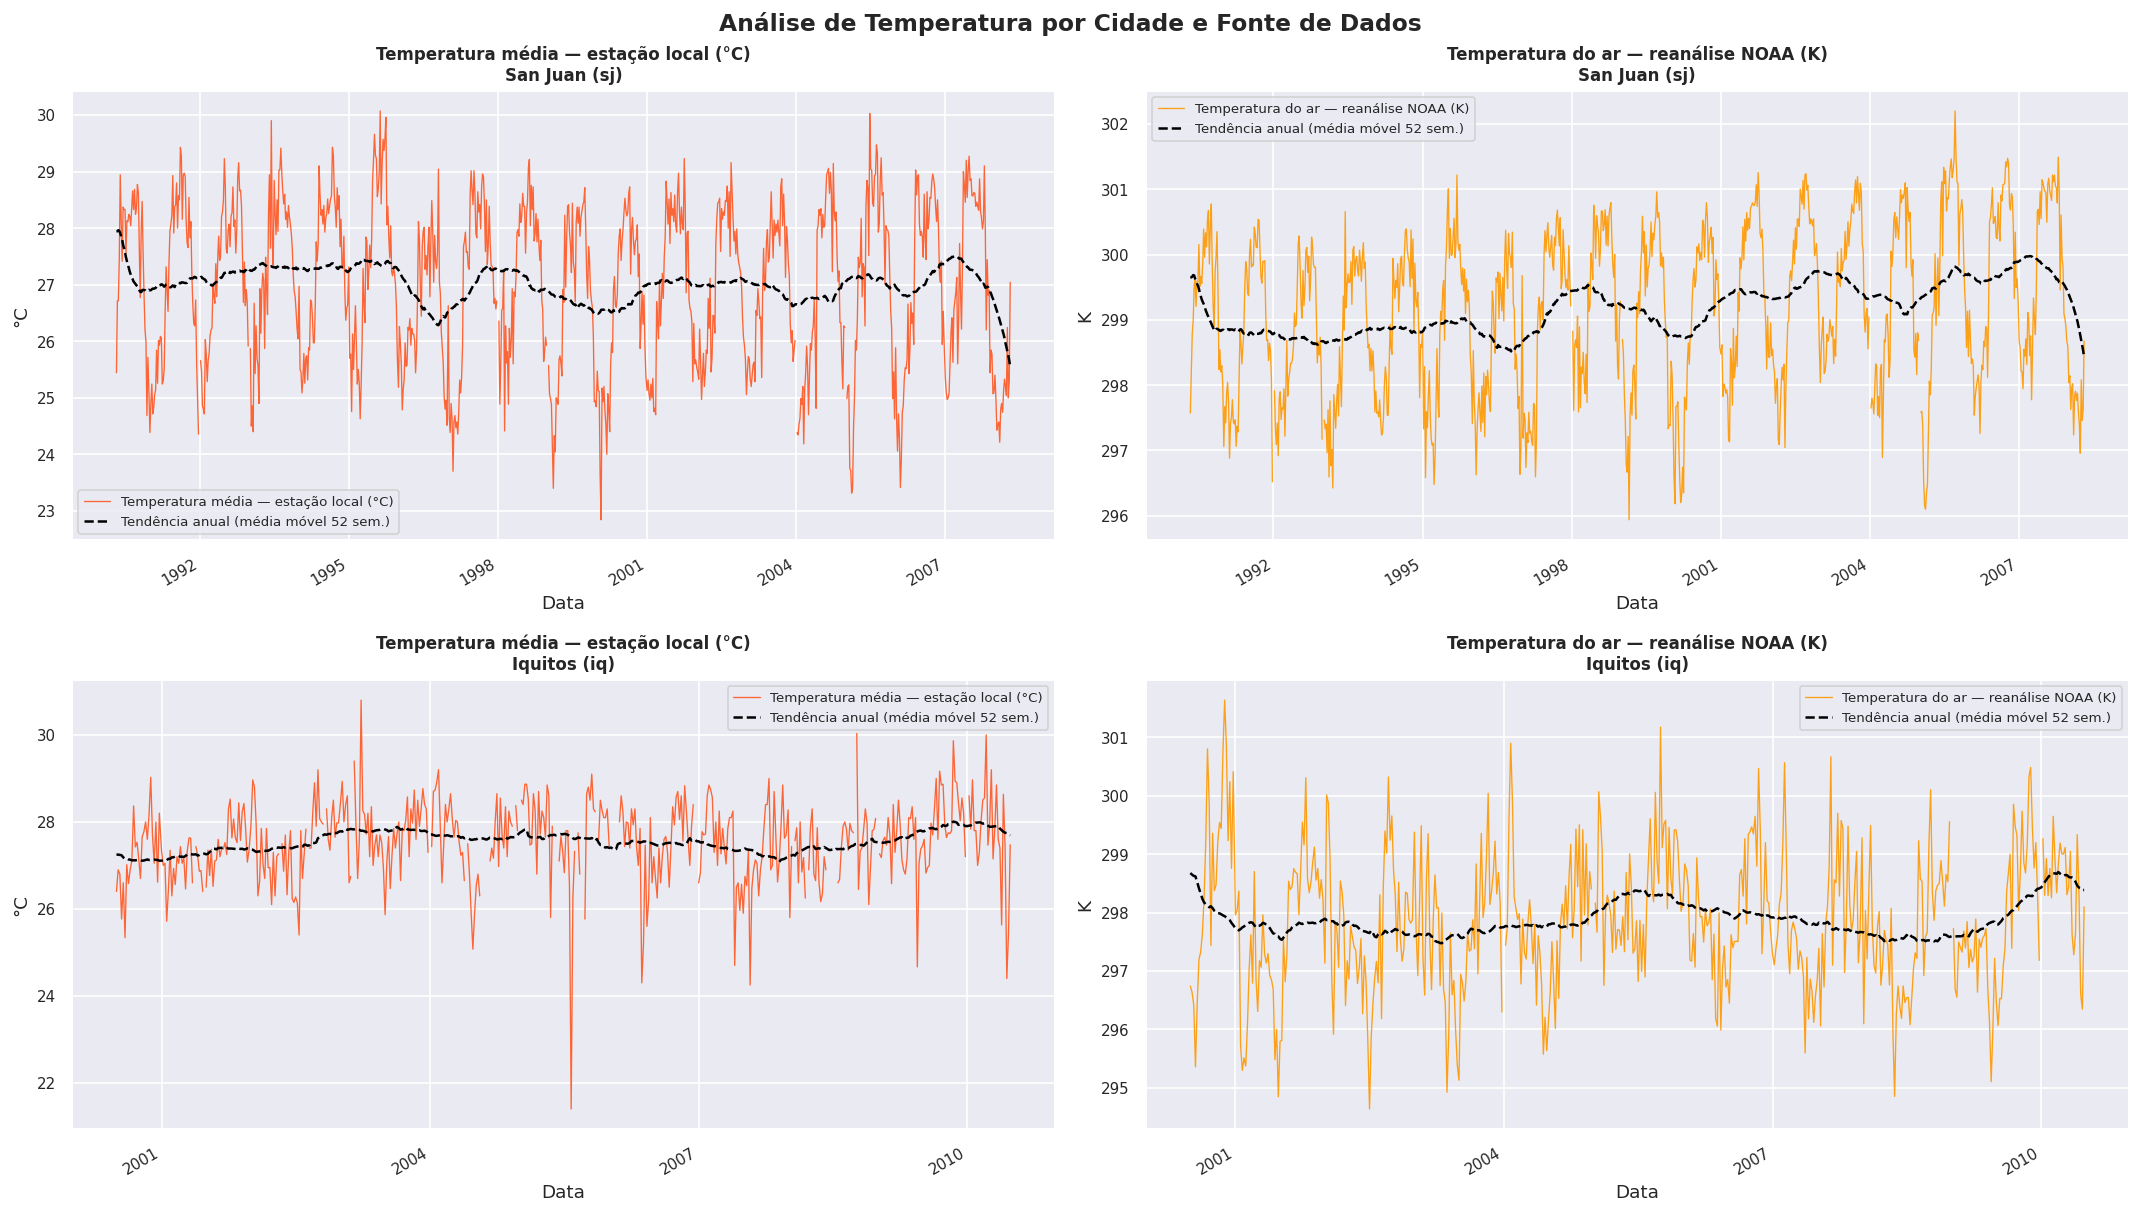

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

temp_configs = [
    ('station_avg_temp_c',        'Temperatura média — estação local (°C)',  'station'),
    ('reanalysis_air_temp_k',     'Temperatura do ar — reanálise NOAA (K)',  'reanalysis'),
]

for row, city, label in zip([0, 1], ['sj', 'iq'],
                             ['San Juan (sj)', 'Iquitos (iq)']):
    sub = df[df['city'] == city].copy()

    for col_idx, (temp_col, temp_label, source) in enumerate(temp_configs):
        ax = axes[row, col_idx]
        cor = '#FF5722' if source == 'station' else '#FF9800'

        ax.plot(sub['week_start_date'], sub[temp_col],
                color=cor, linewidth=0.8, alpha=0.9, label=temp_label)

        # Média móvel anual (52 semanas)
        roll = sub[temp_col].rolling(52, center=True, min_periods=26).mean()
        ax.plot(sub['week_start_date'], roll,
                color='black', linewidth=1.5, linestyle='--',
                label='Tendência anual (média móvel 52 sem.)')

        ax.set_title(f'{temp_label}\n{label}', fontweight='bold', fontsize=10)
        ax.set_xlabel('Data')
        ax.set_ylabel(temp_label.split('(')[1].replace(')', '') if '(' in temp_label else 'Valor')
        ax.legend(fontsize=8)
        ax.xaxis.set_major_locator(mdates.YearLocator(3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.suptitle('Análise de Temperatura por Cidade e Fonte de Dados',
             y=1.01, fontsize=14, fontweight='bold')
plt.show()


 **San Juan** tem temperaturas entre ~23–30°C, típicas do Caribe tropical.
**Iquitos** é ligeiramente mais fresco (21–27°C) mas com menor variação sazonal devido
à proximidade ao equador. A reanálise NOAA (em Kelvin) é coerente com os valores da
estação local (offset de ~273K), mas tende a suavizar picos extremos.
A temperatura tem sazonalidade anual clara em sj (mais quente no verão boreal),
mas praticamente ausente em iq.


### 9. Análise de Humidade

A humidade é o factor climático com maior correlação com os casos de dengue
em ambas as cidades (confirmado na análise de correlação).

Comparamos humidade relativa e humidade específica, que captam aspectos diferentes:
- **Humidade relativa** (`reanalysis_relative_humidity_percent`): percentagem de saturação do ar
- **Humidade específica** (`reanalysis_specific_humidity_g_per_kg`): massa de vapor de água absoluta
- **Temperatura do ponto de orvalho** (`reanalysis_dew_point_temp_k`): temperatura a que o ar satura




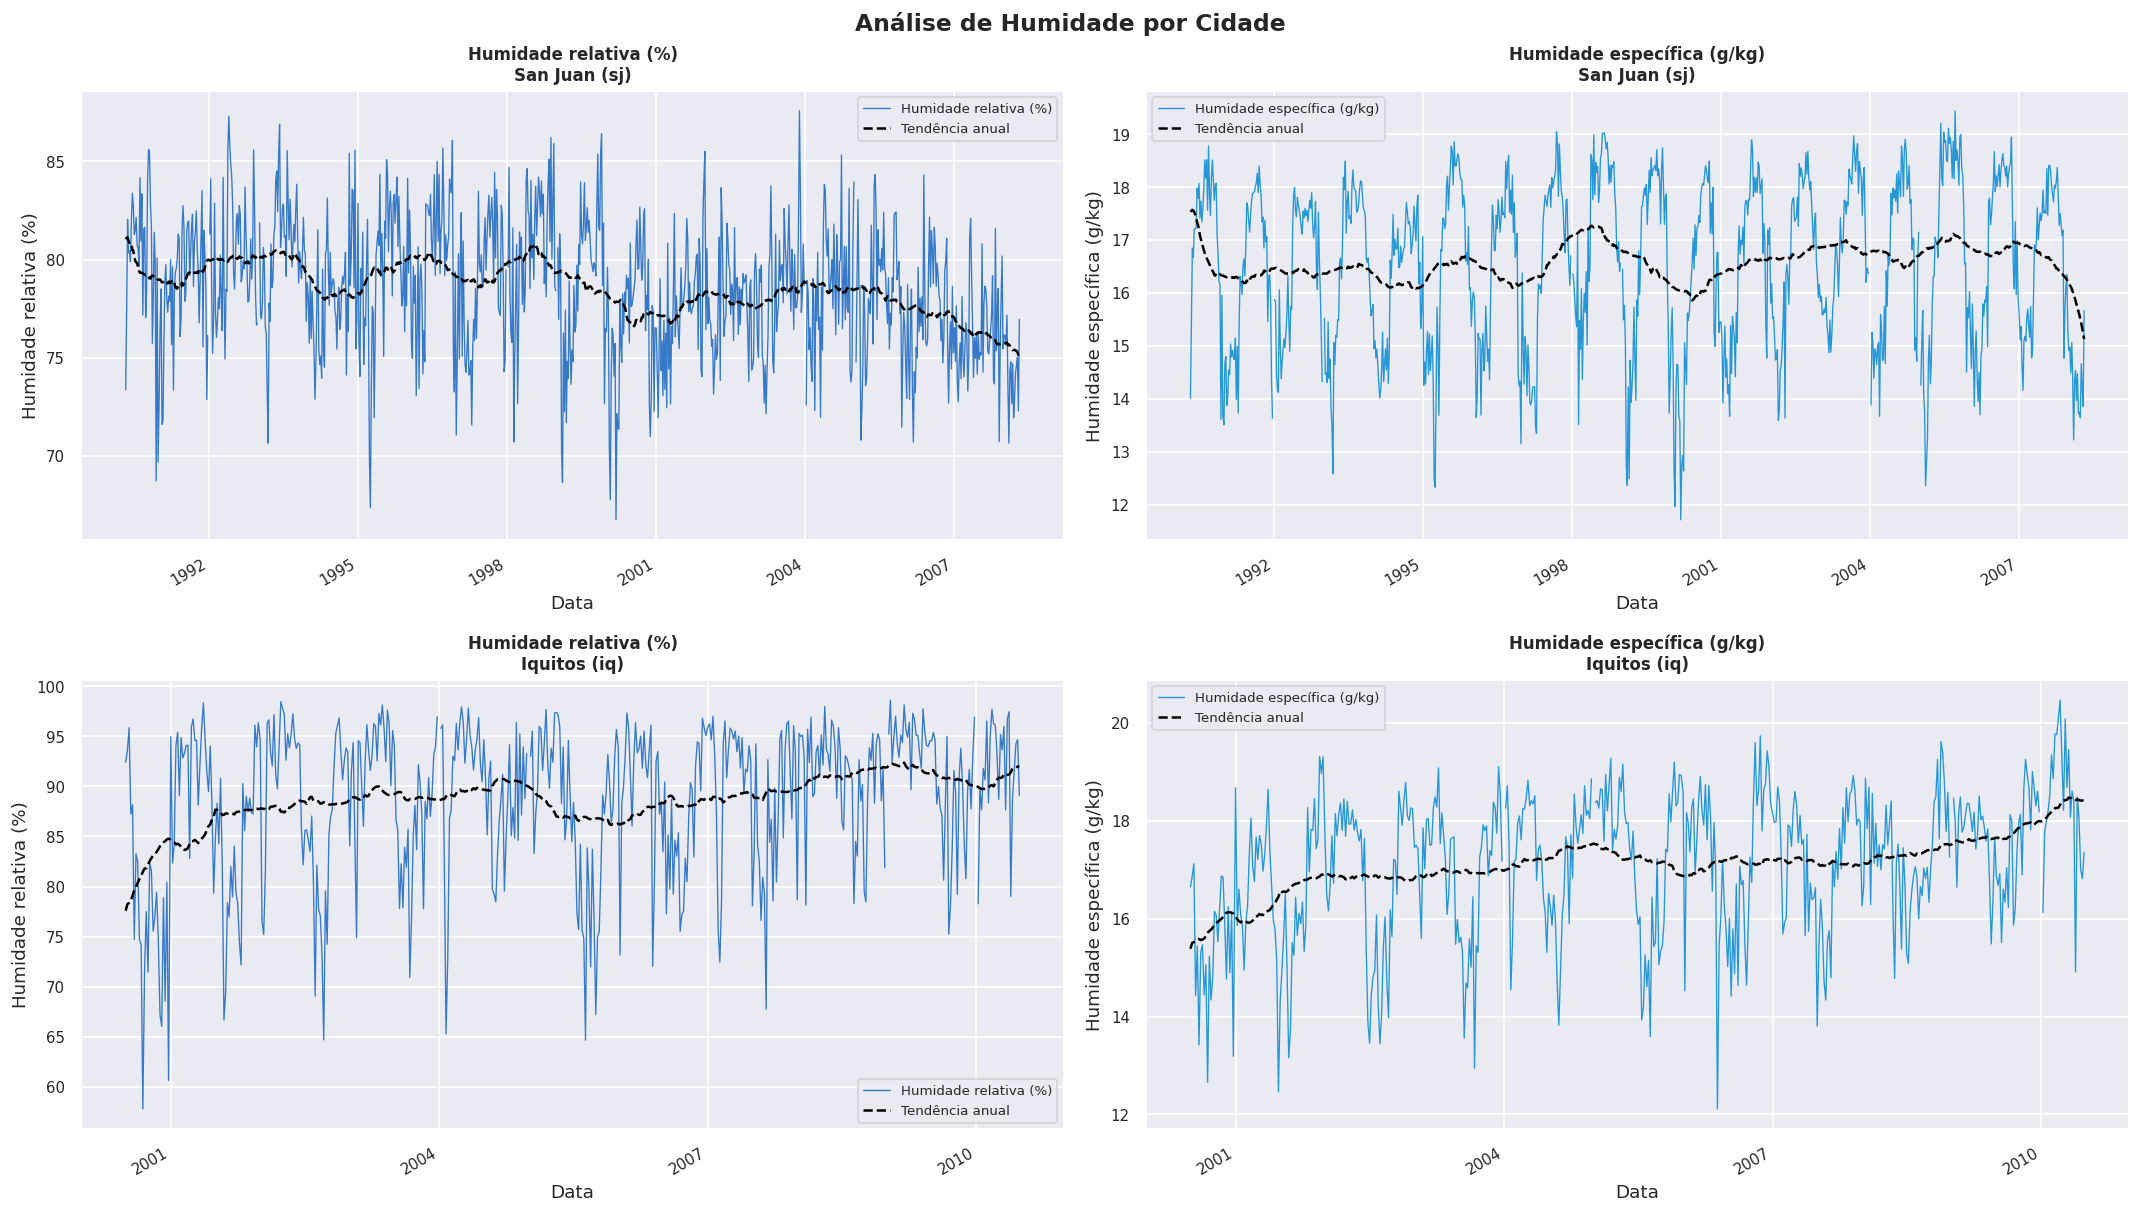

── Correlação de Spearman: humidade vs total_cases com desfasamento (lag) ──
   (positivo = humidade precede os casos, justifica lag features)

  sj:
    lag=0 semanas: r=0.263
    lag=1 semanas: r=0.317
    lag=2 semanas: r=0.370
    lag=3 semanas: r=0.413
    lag=4 semanas: r=0.444

  iq:
    lag=0 semanas: r=0.372
    lag=1 semanas: r=0.352
    lag=2 semanas: r=0.351
    lag=3 semanas: r=0.359
    lag=4 semanas: r=0.324



In [15]:
hum_cols = [
    ('reanalysis_relative_humidity_percent', 'Humidade relativa (%)', '#1565C0'),
    ('reanalysis_specific_humidity_g_per_kg','Humidade específica (g/kg)', '#0288D1'),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for row, city, label in zip([0, 1], ['sj', 'iq'],
                             ['San Juan (sj)', 'Iquitos (iq)']):
    sub = df[df['city'] == city].copy()

    for col_idx, (hcol, hlabel, cor) in enumerate(hum_cols):
        ax = axes[row, col_idx]

        ax.plot(sub['week_start_date'], sub[hcol],
                color=cor, linewidth=0.8, alpha=0.85, label=hlabel)

        roll = sub[hcol].rolling(52, center=True, min_periods=26).mean()
        ax.plot(sub['week_start_date'], roll,
                color='black', linewidth=1.5, linestyle='--',
                label='Tendência anual')

        ax.set_title(f'{hlabel}\n{label}', fontweight='bold', fontsize=10)
        ax.set_xlabel('Data')
        ax.set_ylabel(hlabel)
        ax.legend(fontsize=8)
        ax.xaxis.set_major_locator(mdates.YearLocator(3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.suptitle('Análise de Humidade por Cidade', y=1.01,
             fontsize=14, fontweight='bold')
plt.show()

# Correlação cruzada: humidade vs casos com desfasamento
print("── Correlação de Spearman: humidade vs total_cases com desfasamento (lag) ──")
print("   (positivo = humidade precede os casos, justifica lag features)\n")
for city in ['sj', 'iq']:
    sub = df[df['city'] == city][['reanalysis_specific_humidity_g_per_kg',
                                   'total_cases']].copy()
    print(f"  {city}:")
    for lag in [0, 1, 2, 3, 4]:
        shifted = sub['reanalysis_specific_humidity_g_per_kg'].shift(lag)
        corr = sub['total_cases'].corr(shifted, method='spearman')
        print(f"    lag={lag} semanas: r={corr:.3f}")
    print()


A humidade específica mostra correlação crescente com lag de 1–3 semanas
em ambas as cidades. Isto é epidemiologicamente esperado: o ciclo de vida do mosquito
*Aedes aegypti* desde o ovo até ao adulto capaz de transmitir dengue demora ~10–14 dias,
o que se traduz num desfasamento de 2–3 semanas entre o ambiente favorável e os casos observados.

Esta análise **justifica directamente** a criação de lag features no Notebook "02_Preprocessing.ipynb".

https://brasilescola.uol.com.br/animais/ciclo-vida-aedes-aegypti.htm?utm_source=chatgpt.com
